In [5]:
import pandas as pd
df = pd.read_csv("TheraSAbDab_SeqStruc_OnlineDownload.csv")
df.head()

,Therapeutic,Format,CH1 Isotype,VD LC,Highest_Clin_Trial (Feb '25),Est. Status,HeavySequence,LightSequence,HeavySequence(ifbispec),LightSequence(ifbispec),...,Year Recommended,Target,Companies,Conditions Approved,Conditions Active,Conditions Discontinued,Development Tech,Notes,Genetics (Bispecifics delimited with semicolon),Alternative Therapeutic Names
0,Abagovomab,Whole mAb,G1,Kappa,Phase-III,Discontinued,QVKLQESGAELARPGASVKLSCKASGYTFTNYWMQWVKQRPGQGLD...,DIELTQSPASLSASVGETVTITCQASENIYSYLAWHQQKQGKSPQL...,na,na,...,2007,MUC16/CA125,Menarini,na,na,Ovarian cancer;Pancreatic cancer,NaN,NaN,Murine,ACA 125;ACA125;ACA-125
1,Abazistobart,Whole mAb,G4,Kappa,TBC,TBC,EVKLVESGGGLVQPGGSLRLSCAASGFAFSSYDMSWVRQAPGKRLE...,EIVLTQSPATLSLSPGERATLSCRASQSISNFLHWYQQKPGQAPRL...,na,na,...,na,PDCD1/CD279/PD1,Sunshine Guojian Pharmaceutical (Shanghai) Co....,na,Cancer,na,NaN,NaN,Chimeric and Humanised,609A
2,Abciximab,Fab,G1,Kappa,Approved,NFD,EVQLQQSGTVLARPGASVKMSCEASGYTFTNYWMHWVKQRPGQGLE...,EIVLTQSPVTLSVTPGDSVSLSCRASRDISNNLHWFQQTSHESPRL...,na,na,...,1994,ITGA2B/CD41,Janssen Biologics BV;Eli Lilly,Coronary artery restenosis;Unstable angina pec...,na,Arterial occlusive disorders;Myocardial infarc...,NaN,Sequence sourced through DrugBank. Biosimilars...,Chimeric,c7E3;CentoRx;Centrex;ReoPro
3,Abelacimab,Whole mAb,G1,Lambda,Phase-III,Active,QVQLLESGGGLVQPGGSLRLSCAASGFTFSTAAMSWVRQAPGKGLE...,QSVLTQPPSASGTPGQRVTISCSGSSSNIGSNDVSWYQQLPGTAPK...,na,na,...,2019,F11,Novartis;Anthos Therapeutics;Labcorp Drug Deve...,na,Venous Thromboembolism; Stroke;Thrombosis,na,NaN,Feb '22: Added in missing residues 97 and 98. ...,Genetically human,MAA-868
4,Abiprubart,Whole mAb,G4,Kappa,Phase-II,Active,QVQLVQSGAEVKKPGASVKVSCKASGYTFTNYWMHWVRQAPGQRLE...,EIVLTQSPATLSLSPGERATLSCSASSSVSYMHWYQQKPGQAPRRW...,na,na,...,2024,TNFRSF5/CD40,Primatope Therapeutics;Kiniksa Pharmaceuticals,na,Rheumatoid arthritis;Autoimmune disorders,na,NaN,NaN,Humanised,KPL404;KPL-404;KPL 404


In [6]:
!pip install biopython


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 34.5 MB/s eta 0:00:00


In [7]:
df = df[(df["HeavySequence"].str.len() > 50) & (df["LightSequence"].str.len() > 50)]
df.shape

(1104, 24)

In [8]:
from Bio.SeqUtils.ProtParam import ProteinAnalysis

df["Fv"] = df["HeavySequence"] + df["LightSequence"]
df["pI"] = df["Fv"].apply(lambda seq: ProteinAnalysis(seq).isoelectric_point())

df[["Therapeutic", "pI"]].head()

,Therapeutic,pI
0,Abagovomab,8.908773
1,Abazistobart,8.663793
2,Abciximab,5.922589
3,Abelacimab,7.771845
4,Abiprubart,8.782028


In [9]:
df["GRAVY"] = df["Fv"].apply(lambda seq: ProteinAnalysis(seq).gravy())

df[["Therapeutic", "pI", "GRAVY"]].head()

,Therapeutic,pI,GRAVY
0,Abagovomab,8.908773,-0.386283
1,Abazistobart,8.663793,-0.254911
2,Abciximab,5.922589,-0.253333
3,Abelacimab,7.771845,-0.282328
4,Abiprubart,8.782028,-0.452727


In [10]:
gfp_seq = "MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKFICTTGKLPVPWPTLVTTFSYGVQCFSRYPDHMKQHDFFKSAMPEGYVQERTIFFKDDGNYKTRAEVKFEGDTLVNRIELKGIDFKEDGNILGHKLEYNYNSHNVYIMADKQKNGIKVNFKIRHNIEDGSVQLADHYQQNTPIGDGPVLLPDNHYLSTQSALSKDPNEKRDHMVLLEFVTAAGITHGMDELYK"

gfp = ProteinAnalysis(gfp_seq)
gfp_pI = gfp.isoelectric_point()
gfp_gravy = gfp.gravy()

print("GFP pI:", round(gfp_pI, 2))
print("GFP GRAVY:", round(gfp_gravy, 3))
print("Average antibody pI:", round(df["pI"].mean(), 2))
print("Average antibody GRAVY:", round(df["GRAVY"].mean(), 3))
print("% of antibodies more hydrophobic than GFP:", round((df["GRAVY"] > gfp_gravy).mean() * 100, 1))

GFP pI: 5.67
GFP GRAVY: -0.521
Average antibody pI: 7.73
Average antibody GRAVY: -0.317
% of antibodies more hydrophobic than GFP: 98.7


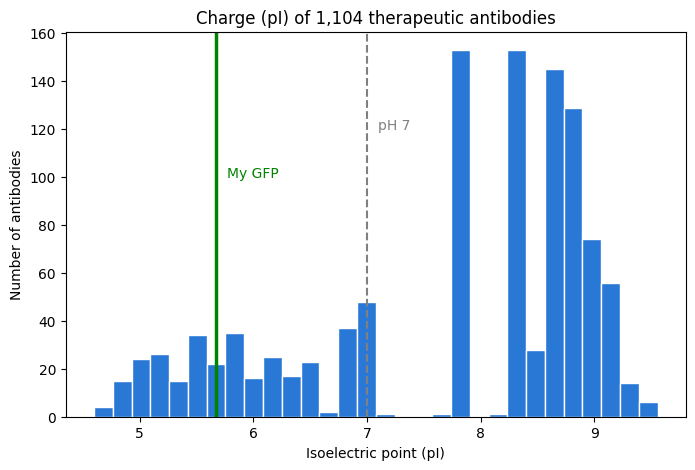

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df["pI"], bins=30, color="#2a78d6", edgecolor="white")
plt.axvline(7, color="gray", linestyle="--", linewidth=1.5)
plt.axvline(gfp_pI, color="#008300", linewidth=2.5)
plt.text(7.1, 120, "pH 7", color="gray")
plt.text(gfp_pI + 0.1, 100, "My GFP", color="#008300")
plt.title("Charge (pI) of 1,104 therapeutic antibodies")
plt.xlabel("Isoelectric point (pI)")
plt.ylabel("Number of antibodies")
plt.savefig("chart1_pI.png", dpi=200, bbox_inches="tight")
plt.show()

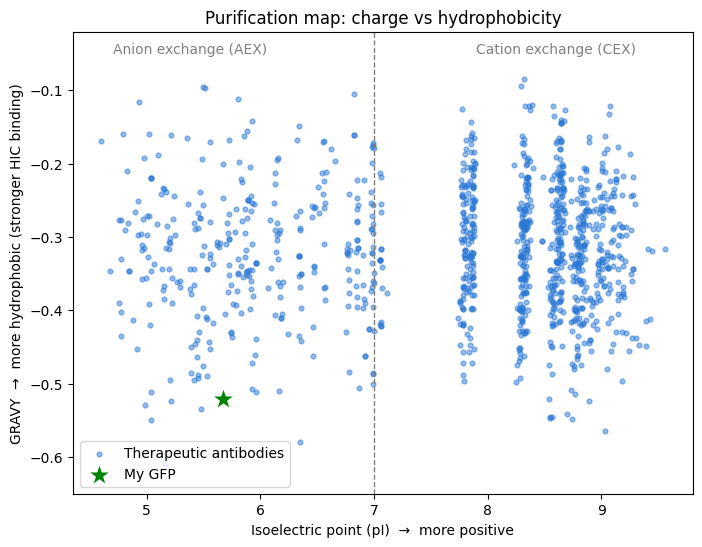

In [12]:
plt.figure(figsize=(8, 6))
plt.scatter(df["pI"], df["GRAVY"], s=12, color="#2a78d6", alpha=0.5, label="Therapeutic antibodies")
plt.scatter(gfp_pI, gfp_gravy, s=300, color="#008300", marker="*", edgecolor="white", label="My GFP")
plt.axvline(7, color="gray", linestyle="--", linewidth=1)
plt.ylim(-0.65, -0.02)
plt.text(4.7, -0.05, "Anion exchange (AEX)", color="gray")
plt.text(7.9, -0.05, "Cation exchange (CEX)", color="gray")
plt.title("Purification map: charge vs hydrophobicity")
plt.xlabel("Isoelectric point (pI)  →  more positive")
plt.ylabel("GRAVY  →  more hydrophobic (stronger HIC binding)")
plt.legend(loc="lower left")
plt.savefig("chart2_map.png", dpi=200, bbox_inches="tight")
plt.show()